# Following single legs

**The question:** `alive_dead_legs.ipynb` follows the mite's outline as a whole and cannot say which leg moved or where a leg is. Can single legs be found in each frame, given a place in pixels, and followed from frame to frame and from recording to recording?

**The approach:** a leg is thin and the body is wide. A disc 5 pixels across fits into the body and not into a leg, so taking away what the disc fits into (a morphological opening) leaves the legs. Each dark spot left next to the body is a leg; its place is measured to a fraction of a pixel, and the legs of one frame are matched to the nearest legs of the frames before (`classes/leg_tracker.py`, tests in `unit_tests/leg_tracker_test.py`).

The run is the long one (`test_run_2026-09-08_Mathis_last_dsRNA`); `scripts/leg_tracks.py` follows the legs of all its mites through all its frames and keeps the result (about 2 minutes the first time).

## Findings (run of 9 October 2026)

One run, one plate, 59 mites, 295 recordings of 10 frames.

- **Yes, single legs can be found and followed, but only two of the eight.** In 69% of the frames of a live mite the tracker finds exactly 2 legs, rarely more than 3. They sit at two spots left and right of the middle of the mite's front, just outside the body's edge. My reading is that each is the front legs of one side lying together; the tracker cannot tell.
- **On drawn mites with known legs the tracker is right.** A leg reaching 1.5 pixels or more past the body is found in 99% of the frames, one reaching 1 pixel in 28%. No leg is found on a mite without legs. Two legs are told apart when their ends are 2.6 pixels apart and are one leg below 2. A leg's swing is seen at 0.9 of what its end did.
- **A leg that does not move is seen to move by 0.15 px.** That is the camera's noise: 0.17 px on a drawn leg, 0.14 px on the legs of dead mites. A real movement has to be larger than about 0.5 px to stand out.
- **When a mite moves, its legs are seen to move by 0.75 px.** That is the median of the recordings labelled moving, against 0.15 px for those labelled still. In 76% of them at least one leg moves by more than 0.48 px, which 99 in 100 legs of dead mites stay below.
- **As a movement score it is clearly worse than the one in use.** AUC 0.967 against 0.997 for moving against still. At each one's best threshold the deaths are 16.9 recordings off with the legs and 3.5 with the score in use.
- **What it misses is its own doing.** In 56 of the 651 recordings labelled moving the legs' places hardly change, yet the pixels at the legs do vary. A leg that gets darker and lighter without changing place, or that jumps further than 1.5 px between two frames, is not seen as moving.
- **The leg's end cannot be followed, only its middle.** Following where each leg ends gives AUC 0.884: the end is where the leg fades into the plate, and the noise decides where that is.
- **The legs get fewer and shorter around death.** A mite shows 2.0 legs reaching 1.75 px from the body while it lives and 1.1 legs reaching 1.05 px once it is dead. The fall starts about 30 recordings before the last labelled movement and ends about 60 after it. How far the legs reach tells alive from dead with AUC 0.88 (0.92 among the mites of one recording).
- **Between recordings the legs' places say less than the whole image.** A live mite's legs are 0.35 px from where they were 10 minutes before, a dead one's 0.04 px (AUC 0.894, against 0.985 for the change of the whole image).
- **A leg keeps its name for 5 recordings in the middle.** One leg in ten is followed over more than 66 recordings. A leg that is not seen for more than 2 recordings and comes back is a new leg to the tracker.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import alive_dead_features as adf
import leg_tracks
from classes import death_calibration
from classes.death_calibration import LabelledRun
from classes.leg_tracker import LegTracker, synthetic_mite

# The project's reporting module switches matplotlib to Agg (no figures) on import.
%matplotlib inline

# Chart style, as in death_time_calibration.ipynb: thin marks, recessive axes and grid, text in ink colours.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8d8c85"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3dc"
LEG_COLORS = [ORANGE, BLUE, AQUA, "#9b5de5", "#c9a227", "#d6457a"]
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "lines.linewidth": 2,
})
pd.set_option("display.precision", 3)
np.seterr(invalid="ignore")

run = adf.load_run()
table, images = adf.features(run)       # the measurements of alive_dead_features.py, for comparison
tracks = leg_tracks.follow_run(run)      # per mite, its legs through every frame of the run
per = leg_tracks.frames_per_recording(run)
group = adf.groups(run)
n_mites, n_recordings = run.moving.shape
last, moved = run.last, run.moved
is_still = run.labelled & ~run.moving
tracker = LegTracker()

def mite_named(name):
    return int(np.flatnonzero(np.array(run.mites) == name)[0])

def zoom(ax, image, pad=8):
    ax.set_xlim(pad - 0.5, image.shape[1] - pad - 0.5); ax.set_ylim(image.shape[0] - pad - 0.5, pad - 0.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

print(f"{run.name}: {n_mites} mites, {n_recordings} recordings of {per} frames; "
      f"{moved.sum()} mites moved at least once, {(~moved).sum()} never")
print(f"legs followed: {sum(len(found) for found in tracks)} tracks, "
      f"{sum(int(found.seen.sum()) for found in tracks) / sum(int(found.count.sum()) for found in tracks):.0%} of the legs found in single frames are in one")

  test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings


test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings of 10 frames; 54 mites moved at least once, 5 never
legs followed: 1024 tracks, 99% of the legs found in single frames are in one


## How a leg is found

One frame of one mite, enlarged 4 times. **Body**: what a disc 5 pixels across fits into. **Leg image**: the frame's darkness minus the body. **Legs**: the maxima of the leg image that lie outside the body, within 4 pixels of its edge, and are at least 12% as dark as the body. The circle is the leg's place (the centre of the darkness around the maximum), the small dot where it ends.

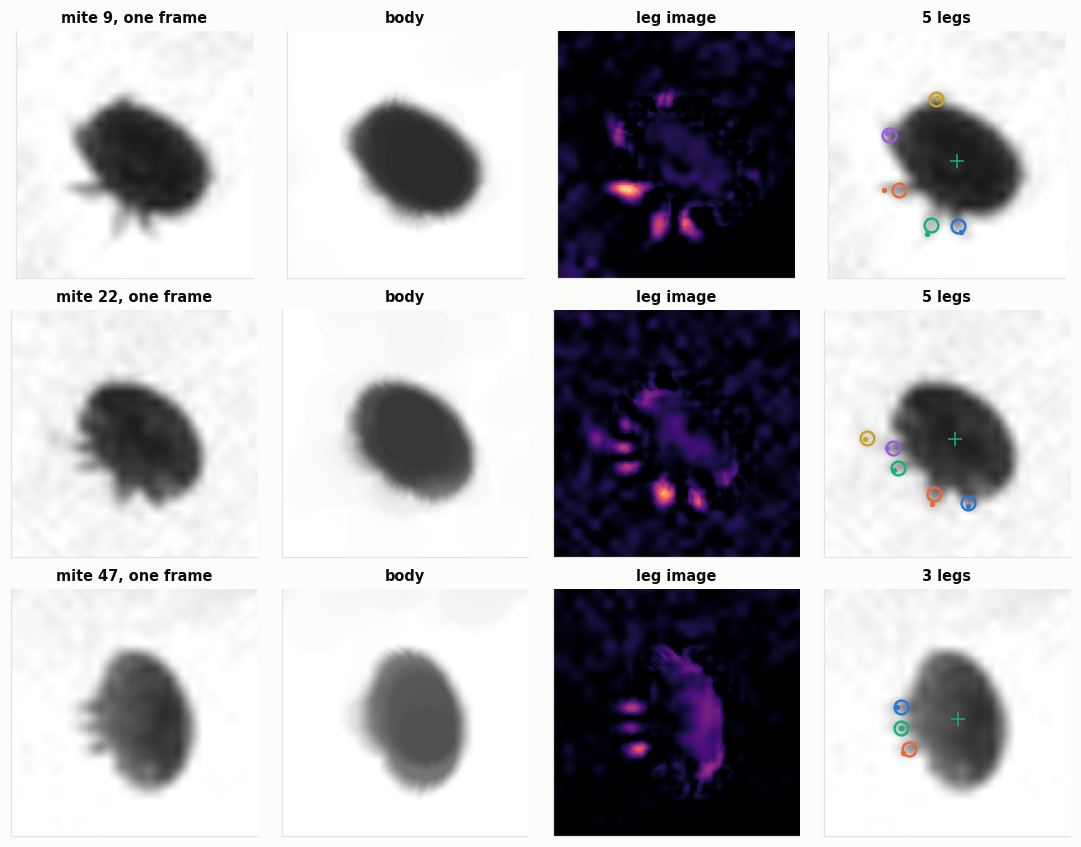

In [2]:
shown = [("9", 29), ("22", 8), ("47", 18)]
fig, axes = plt.subplots(len(shown), 4, figsize=(10, 2.6 * len(shown)))
for row, (name, recording) in enumerate(shown):
    frame = run.grey(mite_named(name))[recording, 0]
    dark, body, leg_image = tracker.leg_image(frame)
    found = tracker.detect(frame)
    extent = (-0.5, frame.shape[1] - 0.5, frame.shape[0] - 0.5, -0.5)
    for ax, picture, title, style in ((axes[row, 0], dark, f"mite {name}, one frame", dict(cmap="gray_r", vmin=0, vmax=0.85)),
                                      (axes[row, 1], body, "body", dict(cmap="gray_r", vmin=0, vmax=0.85)),
                                      (axes[row, 2], leg_image, "leg image", dict(cmap="magma", vmin=0, vmax=0.35)),
                                      (axes[row, 3], dark, f"{len(found)} legs", dict(cmap="gray_r", vmin=0, vmax=0.85))):
        ax.imshow(picture, extent=extent, **style)
        ax.set_title(title, fontsize=9.5)
        zoom(ax, frame, 10)
    for leg in range(len(found)):
        axes[row, 3].plot(*found.xy[leg], "o", markersize=9, markerfacecolor="none", markeredgecolor=LEG_COLORS[leg % 6], markeredgewidth=1.6)
        axes[row, 3].plot(*found.tip[leg], ".", markersize=5, color=LEG_COLORS[leg % 6])
    axes[row, 3].plot(*found.centre, "+", color=AQUA, markersize=9)
plt.tight_layout()
plt.show()

## How good is it? A mite whose legs are known

There is no ground truth for where a leg is. So a mite is drawn (`synthetic_mite()`): a dark oval with legs 1.3 pixels wide at known places, to a fraction of a pixel, blurred as the camera blurs and with the camera's noise, measured here on the bare plate of the real frames. The tracker is then asked the questions it will be asked of the real mites.

In [3]:
# the camera's noise: how much a pixel of bare plate varies over the frames of a recording, in grey levels
patch = run.grey(0)
NOISE = float(np.median(patch[:, :, :4, :4].std(axis=1, ddof=1)))
PLATE = float(np.median(patch[:, :, :4, :4]))
rng = np.random.default_rng(0)
draw = dict(noise=NOISE, plate=PLATE, rng=rng)
print(f"camera noise: {NOISE:.2f} grey levels on a plate of {PLATE:.0f}")

def a_recording(legs_per_frame, shifts=None):
    made = [synthetic_mite(legs, shift=(0, 0) if shifts is None else shifts[index], **draw) for index, legs in enumerate(legs_per_frame)]
    return np.stack([frame for frame, _tips in made]), np.array([tips for _frame, tips in made])

def swing_of(points):
    return 2 * np.sqrt(((points - points.mean(axis=0)) ** 2).sum(axis=-1).mean())

# 1. a leg found, by its length; and legs found on a mite that has none
rows = []
for length in (0, 0.5, 1, 1.5, 2, 3, 4):
    found_it, extra, away = [], [], []
    for trial in range(150):
        angle = rng.uniform(120, 240)
        frame, tips = synthetic_mite([(angle, length)] if length else [], shift=rng.uniform(-0.5, 0.5, 2), **draw)
        legs = tracker.detect(frame)
        near = np.linalg.norm(legs.xy - tips[0], axis=1) < max(length, 1.5) if length and len(legs) else np.zeros(len(legs), bool)
        found_it.append(near.any()); extra.append(len(legs) - near.sum())
        if near.any():
            away.append(np.linalg.norm(legs.xy[near] - tips[0], axis=1).min())
    rows.append({"leg reaches past the body, pixels": length or "no leg", "found": f"{np.mean(found_it):.0%}" if length else "",
                 "other legs found per frame": np.mean(extra), "its place is this far from its end, pixels": np.median(away) if away else np.nan})
display(pd.DataFrame(rows).set_index("leg reaches past the body, pixels"))

# 2. two legs side by side: are they two?
rows = []
for apart in (10, 15, 20, 25, 30, 40):
    two = [len(tracker.detect(synthetic_mite([(a, 3), (a + apart, 3)], shift=rng.uniform(-0.5, 0.5, 2), **draw)[0])) for a in rng.uniform(120, 220, 150)]
    _frame, tips = synthetic_mite([(180, 3), (180 + apart, 3)], noise=0)
    rows.append({"their ends are apart by, pixels": np.linalg.norm(tips[0] - tips[1]), "seen as two": f"{np.mean(np.array(two) == 2):.0%}",
                 "as one": f"{np.mean(np.array(two) == 1):.0%}"})
display(pd.DataFrame(rows).set_index("their ends are apart by, pixels"))

camera noise: 1.49 grey levels on a plate of 100


,found,other legs found per frame,"its place is this far from its end, pixels"
"leg reaches past the body, pixels",,,
no leg,,0.0,NaN
0.5,3%,0.0,0.158
1,28%,0.0,0.191
1.5,99%,0.0,0.174
2,100%,0.0,0.317
3,100%,0.0,0.715
4,100%,0.0,1.157


,seen as two,as one
"their ends are apart by, pixels",,
1.327,0%,100%
1.982,9%,91%
2.633,100%,0%
3.282,100%,0%
3.930,100%,0%
5.229,100%,0%


,its place is seen to swing by,from,to,one track through all frames
"the leg's end swings by, pixels",,,,
7.105e-15,0.174,0.126,0.217,100%
1.917e-01,0.249,0.193,0.294,100%
3.813e-01,0.397,0.347,0.440,100%
7.687e-01,0.719,0.646,0.778,100%
1.131e+00,1.035,0.988,1.137,100%
1.703e+00,1.549,1.476,1.744,100%
2.271e+00,2.048,1.962,2.276,100%
3.413e+00,3.009,1.949,3.232,85%


a leg that does not move is seen to swing by 0.17 px (the noise); on a mite shaken as a whole by 0.3 px, 0.25 px


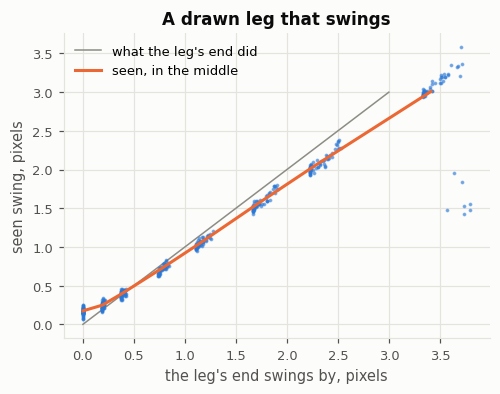

In [4]:
# 3. a leg that swings: how far does the tracker say it moved?
frames_at = np.arange(per)
rows, points = [], []
for sweep in (0, 1, 2, 4, 6, 9, 12, 18):                      # degrees either side, one swing over the recording
    true, measured, followed = [], [], []
    for trial in range(60):
        angles = 180 + rng.uniform(-30, 30) + sweep * np.sin(2 * np.pi * (frames_at / per + rng.uniform()))
        frames, tips = a_recording([[(angle, 3)] for angle in angles])
        found = tracker.track(frames)
        true.append(swing_of(tips[:, 0])); measured.append(LegTracker.movement(found, per)[0])
        followed.append(len(found) == 1 and found.seen.all())
    rows.append({"the leg's end swings by, pixels": np.median(true), "its place is seen to swing by": np.median(measured),
                 "from": np.percentile(measured, 10), "to": np.percentile(measured, 90), "one track through all frames": f"{np.mean(followed):.0%}"})
    points.append((true, measured))
swinging = pd.DataFrame(rows)
display(swinging.set_index("the leg's end swings by, pixels"))

# 4. a mite that does not move a leg, but is moved as a whole (the plate shaking by a third of a pixel)
shaken = [LegTracker.movement(tracker.track(a_recording([[(150, 3), (210, 3)]] * per, rng.normal(0, 0.3, (per, 2)))[0]), per)[0] for trial in range(60)]
STILL_SWING = float(swinging["its place is seen to swing by"][0])
print(f"a leg that does not move is seen to swing by {STILL_SWING:.2f} px (the noise); on a mite shaken as a whole by 0.3 px, {np.median(shaken):.2f} px")

fig, ax = plt.subplots(figsize=(5, 3.6))
ax.plot([0, 3], [0, 3], color=GREY, linewidth=1, label="what the leg's end did")
for true, measured in points:
    ax.plot(true, measured, ".", color=BLUE, markersize=3, alpha=0.5)
ax.plot(swinging["the leg's end swings by, pixels"], swinging["its place is seen to swing by"], color=ORANGE, label="seen, in the middle")
ax.set(xlabel="the leg's end swings by, pixels", ylabel="seen swing, pixels", title="A drawn leg that swings")
ax.legend()
plt.show()

## The legs of real mites, followed through a recording

Each pair of pictures is one mite: a recording in which it is labelled moving, and one 150 recordings after its last labelled movement. The picture is the mean of the recording's frames; on it, the path of each followed leg over the 10 frames (a dot per frame, the legs in different colours). The number is the recording's **leg movement**: the largest swing of any of its legs, in pixels.

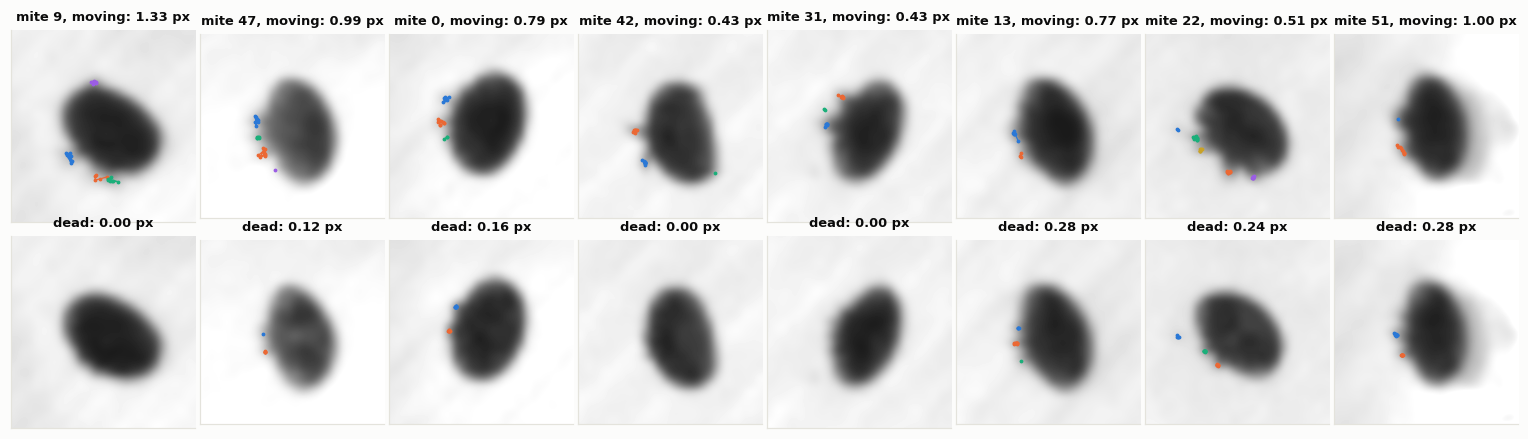

In [5]:
movement = np.array([LegTracker.movement(found, per) for found in tracks])        # (mites, recordings), pixels

def draw_legs(ax, mite, recording, title):
    frames = run.grey(mite)[recording]
    found = tracks[mite].frames(recording * per, (recording + 1) * per)
    image = frames.mean(axis=0)
    ax.imshow(image, cmap="gray", vmin=15, vmax=1.05 * np.median(image[:4]), interpolation="bicubic")
    colour = 0
    for leg in range(len(found)):
        if found.seen[leg].any():
            path = (found.xy[leg] + found.centre)[found.seen[leg]]
            ax.plot(path[:, 0], path[:, 1], "-", color=LEG_COLORS[colour % 6], linewidth=0.8, marker=".", markersize=3)
            colour += 1
    ax.set_title(f"{title}: {movement[mite, recording]:.2f} px", fontsize=8.5)
    zoom(ax, image, 10)

names = ["9", "47", "0", "42", "31", "13", "22", "51"]
fig, axes = plt.subplots(2, len(names), figsize=(1.75 * len(names), 4))
for column, name in enumerate(names):
    mite = mite_named(name)
    moving_recordings = np.flatnonzero(run.moving[mite])
    draw_legs(axes[0, column], mite, moving_recordings[len(moving_recordings) // 2], f"mite {name}, moving")
    draw_legs(axes[1, column], mite, min(last[mite] + 150, n_recordings - 1), "dead")
plt.tight_layout(w_pad=0.3)
plt.show()

## Leg movement against the labels

The same question as for every movement score: does it tell the recordings labelled moving from those labelled still, and where does it put the deaths (`classes/death_calibration.py`, each score at its own best threshold)?

,"AUC, moving against still",still: median,still: 99 in 100 below,still: 999 in 1000 below,moving: median,"death error at its best threshold, recordings",that threshold
,,,,,,,
"leg movement (the legs' places), pixels",0.967,0.150,0.535,0.872,0.751,16.864,0.739
the same with the legs' ends,0.884,0.258,5.038,7.378,1.062,56.034,9.337
movement score in use,0.997,1.572,2.305,3.888,6.406,3.492,4.175


recordings labelled moving with leg movement above what 99 in 100 still ones stay below (0.53 px): 70%; above what 999 in 1000 stay below (0.87 px): 37%
recordings without a followed leg: 0.6% of the moving, 19% of the still, 25% of the dead
a single leg of a dead mite is seen to swing by 0.14 px (median), 99 in 100 by less than 0.48 px
in a recording labelled moving, 2 legs are followed (median); legs swinging by more than 0.48 px: none in 24%, one in 37%, two or more in 39%


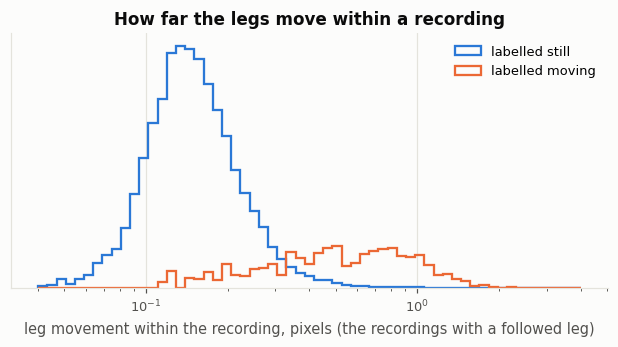

In [6]:
tip_movement = np.array([LegTracker.movement(found, per, of="tip") for found in tracks])
rows = []
for name, values in (("leg movement (the legs' places), pixels", movement), ("the same with the legs' ends", tip_movement),
                     ("movement score in use", table["movement_score"])):
    threshold, error = death_calibration.best_threshold([LabelledRun(values, run.moving, run.labelled)])
    rows.append({"": name, "AUC, moving against still": adf.auc(values[run.moving], values[is_still]),
                 "still: median": np.median(values[is_still]), "still: 99 in 100 below": np.percentile(values[is_still], 99),
                 "still: 999 in 1000 below": np.percentile(values[is_still], 99.9), "moving: median": np.median(values[run.moving]),
                 "death error at its best threshold, recordings": error, "that threshold": threshold})
display(pd.DataFrame(rows).set_index(""))
STILL_99, STILL_999 = np.percentile(movement[is_still], [99, 99.9])
print(f"recordings labelled moving with leg movement above what 99 in 100 still ones stay below ({STILL_99:.2f} px): {(movement[run.moving] > STILL_99).mean():.0%}; "
      f"above what 999 in 1000 stay below ({STILL_999:.2f} px): {(movement[run.moving] > STILL_999).mean():.0%}")
print(f"recordings without a followed leg: {(movement[run.moving] == 0).mean():.1%} of the moving, {(movement[is_still] == 0).mean():.0%} of the still, "
      f"{(movement[group['dead']] == 0).mean():.0%} of the dead")

# how many legs move when a mite moves: a leg moves when it swings by more than 99 in 100 legs of dead mites do
swings = [LegTracker.swings(found, per) for found in tracks]                       # per mite (legs, recordings)
dead_swings = np.concatenate([swing[:, group["dead"][mite]].ravel() for mite, swing in enumerate(swings)])
LEG_LIMIT = float(np.nanpercentile(dead_swings, 99))
followed = np.concatenate([np.isfinite(swing[:, run.moving[mite]]).sum(axis=0) for mite, swing in enumerate(swings)])
moving_legs = np.concatenate([(np.nan_to_num(swing[:, run.moving[mite]]) > LEG_LIMIT).sum(axis=0) for mite, swing in enumerate(swings)])
print(f"a single leg of a dead mite is seen to swing by {np.nanmedian(dead_swings):.2f} px (median), 99 in 100 by less than {LEG_LIMIT:.2f} px")
print(f"in a recording labelled moving, {np.median(followed):.0f} legs are followed (median); legs swinging by more than {LEG_LIMIT:.2f} px: "
      + ", ".join(f"{name} in {np.mean(mask):.0%}" for name, mask in (("none", moving_legs == 0), ("one", moving_legs == 1), ("two or more", moving_legs >= 2))))

fig, ax = plt.subplots(figsize=(7, 3))
bins = np.geomspace(0.04, 4, 60)
for values, colour, name in ((movement[is_still], BLUE, "labelled still"), (movement[run.moving], ORANGE, "labelled moving")):
    ax.hist(values[values > 0], bins=bins, density=True, histtype="step", linewidth=1.5, color=colour, label=name)
ax.set_xscale("log")
ax.set_yticks([])
ax.set(xlabel="leg movement within the recording, pixels (the recordings with a followed leg)", title="How far the legs move within a recording")
ax.legend()
plt.show()

### What it misses

The recordings labelled moving in which the legs are seen to move least: the followed legs on top, and under each where the recording's pixels vary over its frames (what the score in use sees).

56 of the 651 recordings labelled moving have a leg movement below 0.30 px, twice the median of the still ones


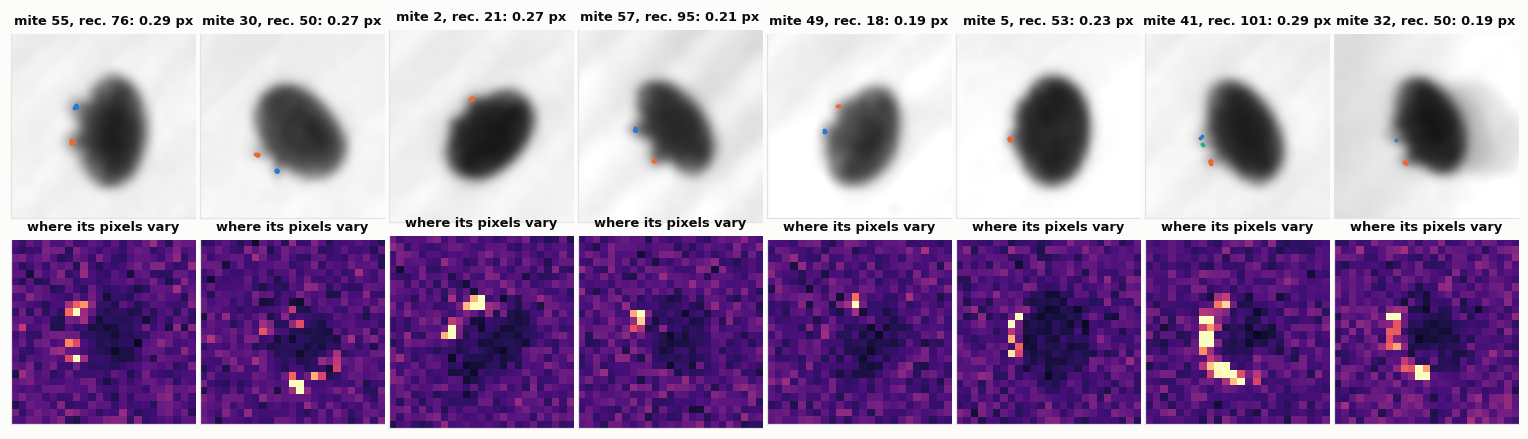

In [7]:
LOW = 2 * float(np.median(movement[is_still]))
missed = np.argwhere(run.moving & (movement < LOW))
print(f"{len(missed)} of the {run.moving.sum()} recordings labelled moving have a leg movement below {LOW:.2f} px, twice the median of the still ones")
pick = missed[np.random.default_rng(1).choice(len(missed), 8, replace=False)]
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for column, (mite, recording) in enumerate(pick):
    draw_legs(axes[0, column], mite, recording, f"mite {run.mites[mite]}, rec. {recording}")
    frames = run.grey(mite)[recording]
    axes[1, column].imshow(frames.std(axis=0), cmap="magma", vmin=0, vmax=6)
    axes[1, column].set_title("where its pixels vary", fontsize=8.5)
    zoom(axes[1, column], frames[0], 10)
plt.tight_layout(w_pad=0.3)
plt.show()

## Where the legs are

Each leg's place is turned with its mite: the body's long axis lies across, and the side with the legs is up. All the frames of the recordings in which the mites are alive (up to the last labelled movement) are put on top of each other. The oval is the mites' body, about.

64200 places of legs of live mites; the body is about 14 x 10 px
direction from the mite's centre, 0 being straight to the side the legs are on: within 30 degrees 80%, within 60 degrees 98%, within 90 degrees 98%
legs found per frame while alive: 2.0 in the middle; the most a mite shows (in 1 frame in 20): 3 in the middle, 5 at most. A mite has 8.


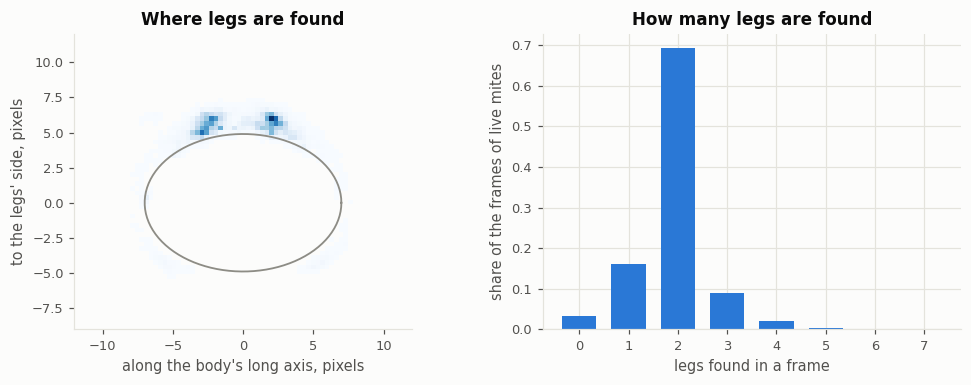

In [8]:
in_frame = [leg_tracks.in_body_frame(found) for found in tracks]                  # per mite (legs, frames, 2): along, across
alive_frames = np.repeat(group["alive"], per, axis=1)
places = np.concatenate([frame[:, alive_frames[mite]].reshape(-1, 2) for mite, frame in enumerate(in_frame)])
places = places[np.isfinite(places[:, 0])]
direction = np.degrees(np.arctan2(places[:, 0], places[:, 1]))                     # 0: straight ahead, 90: along the long axis
def half_axes(image):
    # of the body in one image: from how far its points lie from its centre (for an oval, half an axis is twice that)
    _dark, body, _legs = tracker.leg_image(image)
    ys, xs = np.nonzero(body > 0.5 * body.max())
    return 2 * np.sqrt(np.linalg.eigvalsh(np.cov(np.stack([xs, ys])))[::-1]) / tracker.scale

half_long, half_short = np.median([half_axes(image[0]) for image in images], axis=0)
print(f"{len(places)} places of legs of live mites; the body is about {2 * half_long:.0f} x {2 * half_short:.0f} px")
print("direction from the mite's centre, 0 being straight to the side the legs are on: "
      + ", ".join(f"within {limit} degrees {np.mean(np.abs(direction) <= limit):.0%}" for limit in (30, 60, 90)))
count = np.array([leg_tracks.counts(found, per) for found in tracks])              # (mites, recordings): legs found per frame
most = np.array([np.percentile(found.count[alive_frames[mite]], 95) if alive_frames[mite].any() else np.nan for mite, found in enumerate(tracks)])
print(f"legs found per frame while alive: {np.median(count[group['alive']]):.1f} in the middle; "
      f"the most a mite shows (in 1 frame in 20): {np.nanmedian(most):.0f} in the middle, {np.nanmax(most):.0f} at most. A mite has 8.")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), gridspec_kw={"width_ratios": [1.25, 1]})
axes[0].hist2d(places[:, 0], places[:, 1], bins=[np.arange(-12, 12.01, 0.33)] * 2, cmap="Blues", cmin=1)
turn = np.linspace(0, 2 * np.pi, 100)
axes[0].plot(half_long * np.cos(turn), half_short * np.sin(turn), color=GREY, linewidth=1.2)
axes[0].set_aspect("equal"); axes[0].set_xlim(-12, 12); axes[0].set_ylim(-9, 12); axes[0].grid(False)
axes[0].set(xlabel="along the body's long axis, pixels", ylabel="to the legs' side, pixels", title="Where legs are found")
frames_alive = np.concatenate([found.count[alive_frames[mite]] for mite, found in enumerate(tracks)])
axes[1].bar(np.arange(8), [np.mean(frames_alive == n) for n in range(8)], color=BLUE, width=0.7)
axes[1].set(xlabel="legs found in a frame", ylabel="share of the frames of live mites", title="How many legs are found")
plt.tight_layout()
plt.show()

## The legs through the run

Each panel is one mite, each colour one followed leg. Across: where the leg is around the mite, as the direction from the mite's centre (0: straight to the legs' side). Down: the run, a dot per recording. A leg that moves wanders; a leg that has stopped is a straight line; a leg drawn in ends. The dashed line is the last labelled movement.

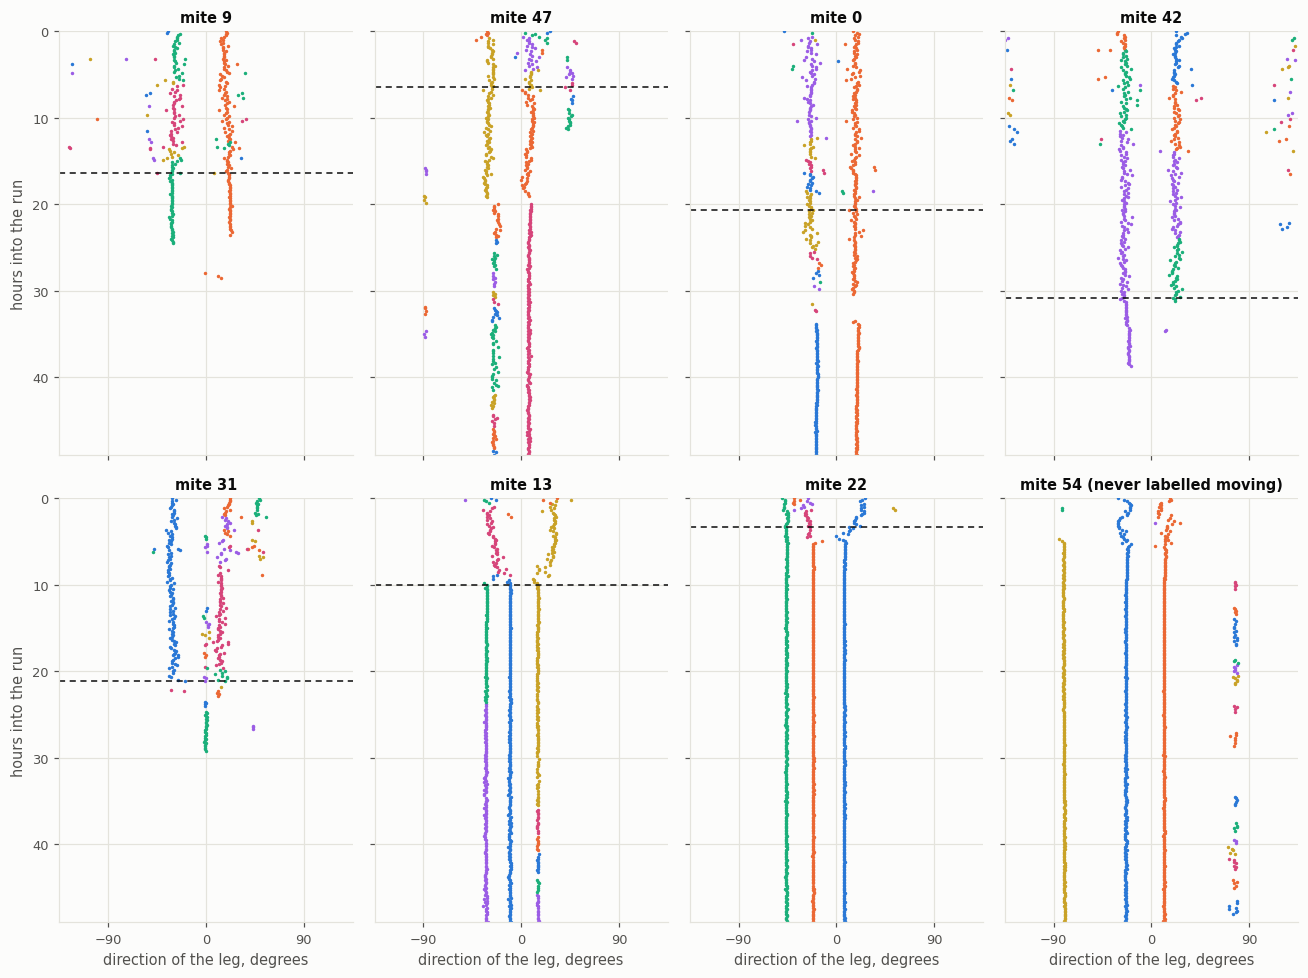

a leg is followed over 5 recordings in the middle (a quarter of them over more than 17, 1 in 10 over more than 66); a mite has 13 tracks over the run


In [9]:
def by_recording(values):
    """(legs, frames, ...) as the mean over each recording's frames: (legs, recordings, ...)."""
    values = values.reshape(len(values), n_recordings, per, *values.shape[2:])
    seen = np.isfinite(values).sum(axis=2)
    return np.where(seen > 0, np.nansum(values, axis=2) / np.maximum(seen, 1), np.nan)

names = ["9", "47", "0", "42", "31", "13", "22", "54"]
fig, axes = plt.subplots(2, 4, figsize=(12, 9), sharex=True, sharey=True)
hours = run.times / 60
for ax, name in zip(axes.ravel(), names):
    mite = mite_named(name)
    place = by_recording(in_frame[mite])
    where = np.degrees(np.arctan2(place[..., 0], place[..., 1]))
    for leg in np.argsort(-np.isfinite(where).sum(axis=1)):
        ax.plot(where[leg], hours, ".", markersize=2.5, color=LEG_COLORS[leg % 6])
    if moved[mite]:
        ax.axhline(hours[last[mite]], color=INK, linewidth=1, linestyle=(0, (4, 3)))
    ax.set_title(f"mite {name}" + ("" if moved[mite] else " (never labelled moving)"), fontsize=9.5)
    ax.set_xlim(-135, 135); ax.set_ylim(hours[-1], 0); ax.set_xticks([-90, 0, 90])
for ax in axes[-1]:
    ax.set_xlabel("direction of the leg, degrees")
for ax in axes[:, 0]:
    ax.set_ylabel("hours into the run")
plt.tight_layout()
plt.show()

spans = np.concatenate([[np.ptp(np.flatnonzero(seen)) + 1 for seen in found.seen] for found in tracks if len(found)]) / per
print(f"a leg is followed over {np.median(spans):.0f} recordings in the middle (a quarter of them over more than {np.percentile(spans, 75):.0f}, "
      f"1 in 10 over more than {np.percentile(spans, 90):.0f}); a mite has {np.median([len(found) for found in tracks]):.0f} tracks over the run")

## What the legs do when the mite dies

Every mite's recordings are lined up on its last labelled movement. Three things are followed: how many legs are found per frame, how far they reach from the body's edge, and how far they are from where they were in the recording before.

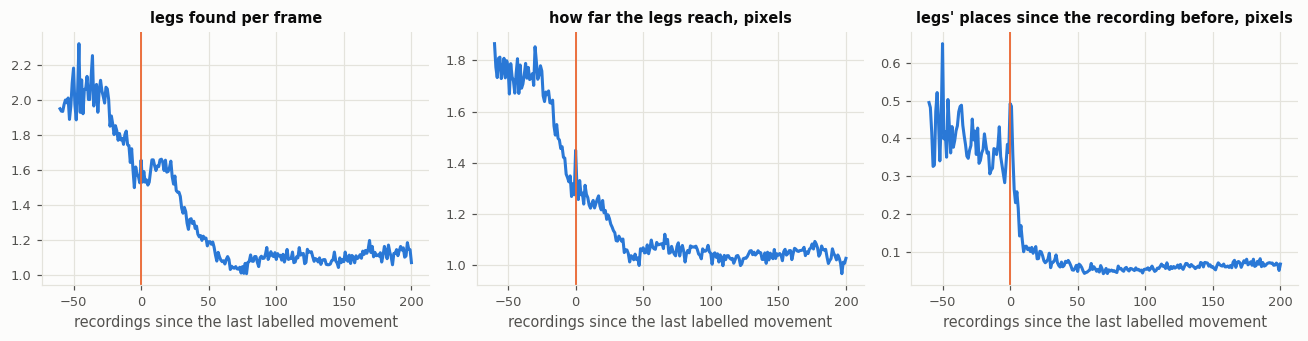

,legs found per frame,"how far they reach, pixels","moved since the recording before, pixels"
recordings since the last labelled movement,,,
-60 to -30,2.035,1.748,0.346
-30 to -10,1.885,1.639,0.293
-10 to 0,1.621,1.354,0.274
0 to 10,1.580,1.300,0.160
10 to 30,1.582,1.210,0.051
30 to 60,1.229,1.060,0.039
60 to 120,1.084,1.052,0.038
120 to 200,1.106,1.043,0.052


,"AUC, alive against dead",same time,same mite,distance
,,,,
legs found per frame,0.778,0.778,0.780,1.183
how far the legs reach,0.878,0.916,0.812,1.900
legs' places since the recording before,0.894,0.892,0.867,1.290
change of the whole image (dead_mite_change.ipynb),0.985,0.990,0.975,1.859


legs' places differ from the recording before by more than the noise gives (0.30 px) in 55% of the alive recordings and 0.36% of the dead ones
the last recording in which a leg had changed place, against the last labelled movement: +3 recordings in the middle (middle half +0 to +10), within 5 in 46% of the mites


In [10]:
length = np.array([leg_tracks.lengths(found, per) for found in tracks])           # (mites, recordings), pixels
changes = [leg_tracks.place_change(found, per) for found in tracks]
place_change = np.array([change for change, _floor in changes])                    # (mites, recordings), pixels since the recording before
floor = np.array([floor for _change, floor in changes])
PLACE_LIMIT = float(np.percentile(floor[is_still], 99.9))

since = np.arange(-60, 201)
def lined_up(values):
    out = np.full((n_mites, len(since)), np.nan)
    for mite in np.flatnonzero(moved):
        at = last[mite] + since
        inside = (at >= 0) & (at < n_recordings)
        out[mite, inside] = values[mite, at[inside]]
    return np.nanmean(out, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, values, name in ((axes[0], count, "legs found per frame"), (axes[1], length, "how far the legs reach, pixels"),
                         (axes[2], place_change, "legs' places since the recording before, pixels")):
    ax.plot(since, lined_up(values), color=BLUE)
    ax.axvline(0, color=ORANGE, linewidth=1.2)
    ax.set(xlabel="recordings since the last labelled movement", title=name)
    ax.title.set_fontsize(9.5)
plt.tight_layout()
plt.show()

rows = []
for first, end in [(-60, -30), (-30, -10), (-10, 0), (0, 10), (10, 30), (30, 60), (60, 120), (120, 200)]:
    parts = [(mite, slice(max(last[mite] + first, 0), max(last[mite] + end, 0))) for mite in np.flatnonzero(moved)]
    rows.append({"recordings since the last labelled movement": f"{first} to {end}",
                 "legs found per frame": np.mean(np.concatenate([count[m, s] for m, s in parts])),
                 "how far they reach, pixels": np.nanmean(np.concatenate([length[m, s] for m, s in parts])),
                 "moved since the recording before, pixels": np.nanmedian(np.concatenate([place_change[m, s] for m, s in parts]))})
display(pd.DataFrame(rows).set_index("recordings since the last labelled movement"))

alive_pairs, dead_pairs = adf.both(group["alive"]), adf.both(group["dead"])
rows = [{"": name, **adf.separation(values, positive, negative)} for name, values, positive, negative in (
    ("legs found per frame", count, group["alive"], group["dead"]),
    ("how far the legs reach", length, group["alive"], group["dead"]),
    ("legs' places since the recording before", place_change, alive_pairs, dead_pairs),
    ("change of the whole image (dead_mite_change.ipynb)", table["image_change"], alive_pairs, dead_pairs))]
display(pd.DataFrame(rows).set_index("").rename(columns={"auc": "AUC, alive against dead", "same_time": "same time", "same_mite": "same mite"}))
print(f"legs' places differ from the recording before by more than the noise gives ({PLACE_LIMIT:.2f} px) in "
      f"{(place_change[alive_pairs] > PLACE_LIMIT).mean():.0%} of the alive recordings and {(place_change[dead_pairs] > PLACE_LIMIT).mean():.2%} of the dead ones")
legs_stop = adf.last_change(place_change, PLACE_LIMIT)
difference = (legs_stop - last)[moved]
print(f"the last recording in which a leg had changed place, against the last labelled movement: {np.median(difference):+.0f} recordings in the middle "
      f"(middle half {np.percentile(difference, 25):+.0f} to {np.percentile(difference, 75):+.0f}), within 5 in {np.mean(np.abs(difference) <= 5):.0%} of the mites")

## What this is good for, and what not

**Good for**

- **Seeing what a mite's legs did.** The picture of the legs through the run shows each leg wandering while the mite lives and standing still from one recording on, as a place on the mite in pixels. For a mite whose death is in doubt it can be read at a glance.
- **A second sign of death that is not movement.** The legs get fewer and shorter around death. It needs no frames within a recording, only one picture, and it is not the body's shrinking of `alive_dead_shrinkage.ipynb`. `alive_dead_legs.ipynb` found that what sticks out of the body does not get smaller; its split of body and legs was rough, and here the legs themselves are measured.
- **Saying where on the mite something moved.** A leg movement comes with the leg's place, so a movement at the legs can be told from one elsewhere in the patch (a speck, a neighbour).

**Not good for**

- **Replacing the score in use.** It is worse at telling moving from still and much worse at placing the deaths. It throws away everything in the picture that is not the place of a dark spot.
- **Counting legs or naming them.** Two of eight are found. Legs closer than 2 pixels are one, and a leg shorter than 1.5 pixels past the body is mostly not found.
- **Mites without a followed leg.** 19% of the recordings labelled still and 25% of the dead ones have no followed leg at all, and their leg movement is then 0 by default.

**Not known**

- Whether the legs are really drawn in around death, or only get lighter and fall below the tracker's threshold. Both would look the same here.
- Whether it holds on another run, camera or resolution. The disc's size, the threshold and the linking distance were chosen on this run, by the AUC above, among about 20 settings tried (that scan is not in this notebook). So the AUC of 0.967 is, if anything, flattering.
- Whether the drawn mites are fair. Their legs are straight, evenly dark and stand clear of the body. Real legs are fainter and overlap, so the tracker is probably worse on real mites than the numbers on drawn ones say.
